In [0]:
abrimos el archivo root

## Histogramas por sabor

`plot_por_sabor` sirve para cualquier rama con un valor por jet y la misma estructura que `Jet.Flavor`, por ejemplo `Jet.PT`, `Jet.Eta`, `Jet.Phi` o `Jet.Mass`. No se debe usar directamente con `Track.*`: esas ramas contienen tracks por evento, no un valor asociado a cada jet.

In [1]:
import uproot
import awkward as ak
import numpy as np
import hist
import mplhep as hep
import matplotlib.pyplot as plt

hep.style.use(hep.style.CMS)

In [2]:
files = [
    "~/mg5amcnlo/campaigns/tomi/YDRAY-run_01_delphes_events.root",
    "~/mg5amcnlo/campaigns/tomi/YDRAY-run_02_delphes_events.root",
]

def load(branches):
    return uproot.concatenate(
        {file: "Delphes" for file in files},
        branches,
        library="ak"
    )

jets = load([
    "Jet.PT",
    "Jet.Eta",
    "Jet.Phi",
    "Jet.Mass",
    "Jet.Flavor"
])

In [3]:

def plot(variable, bins=50, rango=None):
    data = load([variable])[variable]
    data = ak.to_numpy(ak.flatten(data, axis=None))
    data = data[np.isfinite(data)]

    if rango is None:
        xmin, xmax = data.min(), data.max()
    else:
        xmin, xmax = rango

    h = hist.Hist.new.Reg(
        bins, xmin, xmax,
        name="x",
        label=variable
    ).Double()

    h.fill(x=data)

    # Figura pequeña y horizontal
    fig, ax = plt.subplots(figsize=(8, 4))
    TAM_TEXTO = 15
    ax.tick_params(axis="both", labelsize=TAM_TEXTO)

    hep.histplot(
        h,
        histtype="step",
        yerr=False,
        ax=ax
    )

    ax.set_xlabel(variable, fontsize=TAM_TEXTO)
    ax.set_ylabel("Entries", fontsize=TAM_TEXTO)
    
    resumen = (
    f"min = {data.min():.3g}\n"
    f"max = {data.max():.3g}\n"
    f"media = {data.mean():.3g}\n"
    f"std = {data.std():.3g}"
    )

    ax.text(
        0.98,
        0.97,
        resumen,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=TAM_TEXTO,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "edgecolor": "gray",
            "alpha": 0.85,
        },
    )

    plt.show()

    return h

In [4]:
def plot_por_sabor(variable, bins=50, rango=None):
    datos = load([variable, "Jet.Flavor"])
    valores_por_evento = datos[variable]
    sabores_por_evento = datos["Jet.Flavor"]

    try:
        misma_estructura = np.array_equal(
            ak.to_numpy(ak.num(valores_por_evento, axis=1)),
            ak.to_numpy(ak.num(sabores_por_evento, axis=1)),
        )
    except Exception as error:
        raise ValueError(
            f"{variable} no es una rama por jet comparable con Jet.Flavor. "
            "Usa una rama Jet.* con un valor por jet."
        ) from error

    if not misma_estructura:
        raise ValueError(f"{variable} y Jet.Flavor no tienen un valor por el mismo jet.")

    valores = ak.to_numpy(ak.flatten(valores_por_evento, axis=None))
    sabores = ak.to_numpy(ak.flatten(sabores_por_evento, axis=None))
    validos = np.isfinite(valores) & np.isfinite(sabores)
    valores, sabores = valores[validos], sabores[validos]

    if len(valores) == 0:
        raise ValueError(f"{variable} no contiene valores finitos.")

    xmin, xmax = rango if rango is not None else (valores.min(), valores.max())
    if xmin == xmax:
        xmin, xmax = xmin - 0.5, xmax + 0.5

    sabores_conocidos = np.zeros(len(sabores), dtype=bool)
    categorias = [
        ("b (5)", np.abs(sabores) == 5, "tab:red"),
        ("c (4)", np.abs(sabores) == 4, "tab:orange"),
        ("g (21)", sabores == 21, "tab:blue"),
        ("uds (1, 2, 3)", np.isin(np.abs(sabores), [1, 2, 3]), "tab:green"),
    ]

    fig, ax = plt.subplots(figsize=(8, 4))
    
    histogramas = {}
    for nombre, mascara, color in categorias:
        sabores_conocidos |= mascara
        if not np.any(mascara):
            continue
        h = hist.Hist.new.Reg(bins, xmin, xmax, name="x", label=variable).Double()
        h.fill(x=valores[mascara])
        hep.histplot(h, histtype="step", yerr=False, color=color, label=nombre, ax=ax)
        histogramas[nombre] = h

    desconocidos = ~sabores_conocidos
    if np.any(desconocidos):
        h = hist.Hist.new.Reg(bins, xmin, xmax, name="x", label=variable).Double()
        h.fill(x=valores[desconocidos])
        hep.histplot(h, histtype="step", yerr=False, color="tab:gray", label="otro/desconocido", ax=ax)
        histogramas["otro/desconocido"] = h

    TAM_TEXTO = 13

    ax.set_xlabel(variable, fontsize=TAM_TEXTO)
    ax.set_ylabel("Entries", fontsize=TAM_TEXTO)
    ax.tick_params(axis="both", labelsize=TAM_TEXTO)

    ax.legend(
        title="Jet.Flavor",
        fontsize=TAM_TEXTO,
        title_fontsize=TAM_TEXTO,
    )
    plt.show()
    #return histogramas


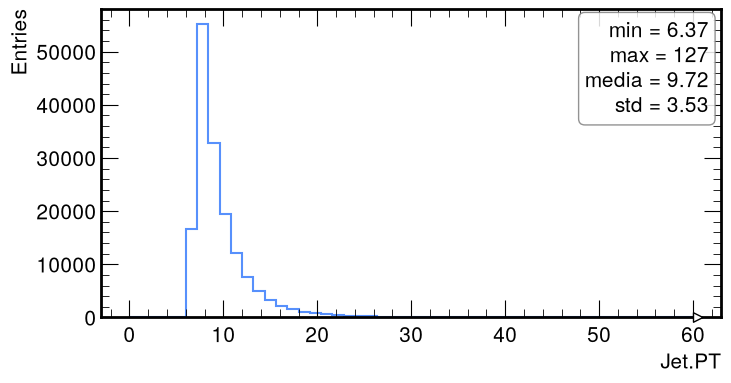

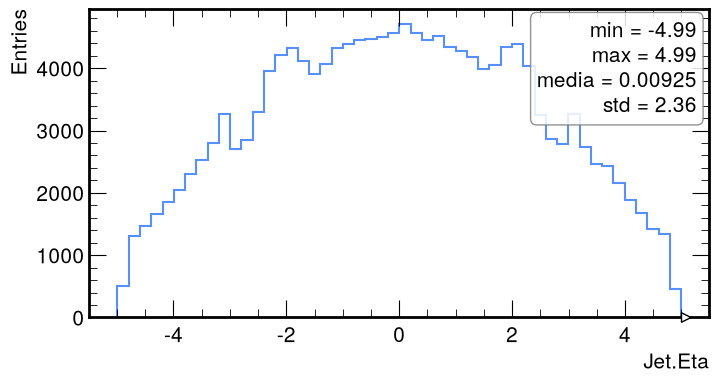

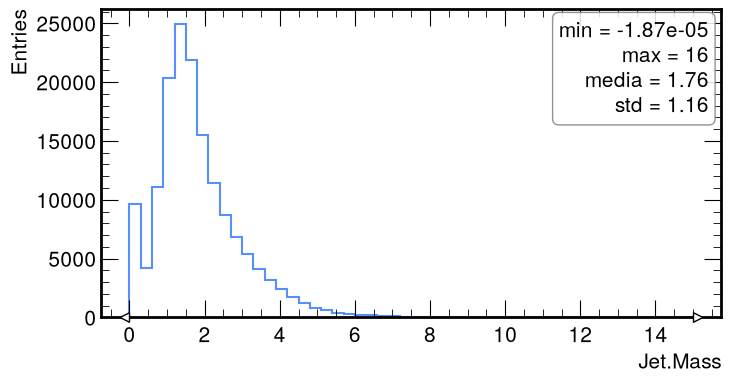

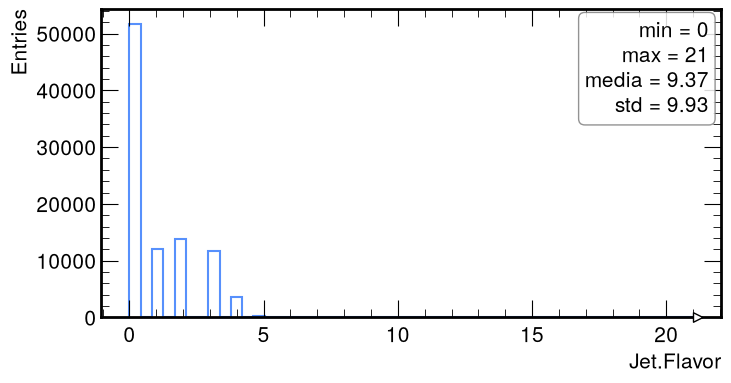

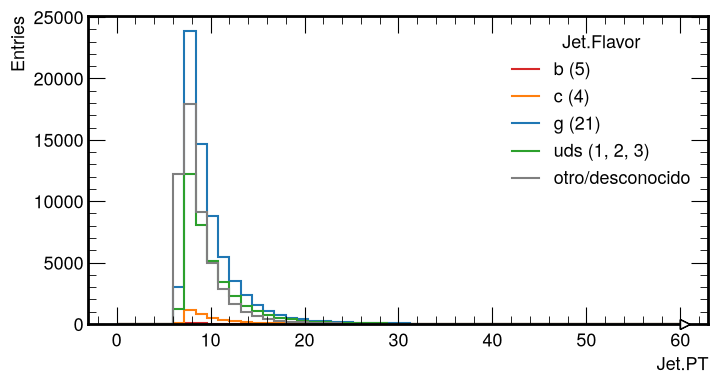

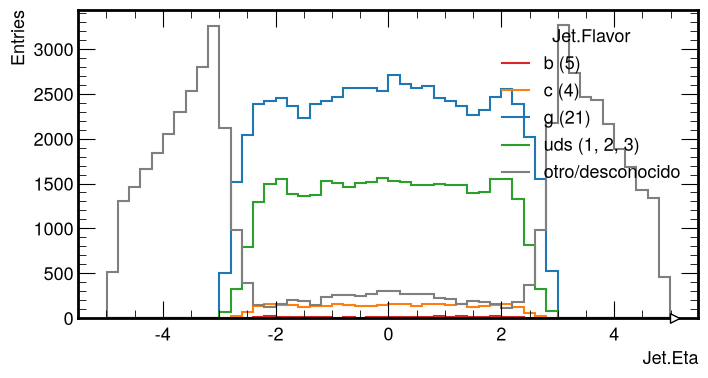

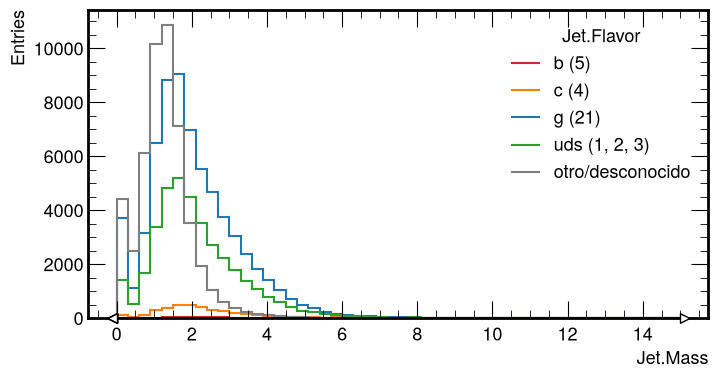

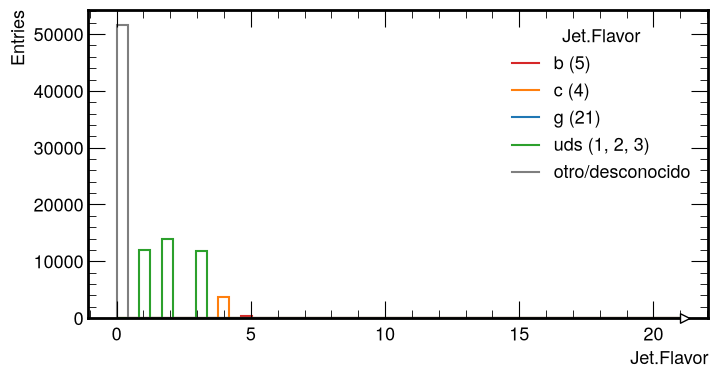

In [5]:
plot("Jet.PT", rango=(0, 60))
plot("Jet.Eta")
plot("Jet.Mass", rango = (0, 15))
plot("Jet.Flavor")
plot_por_sabor("Jet.PT", rango=(0, 60))
plot_por_sabor("Jet.Eta")
plot_por_sabor("Jet.Mass", rango = (0, 15))
plot_por_sabor("Jet.Flavor")

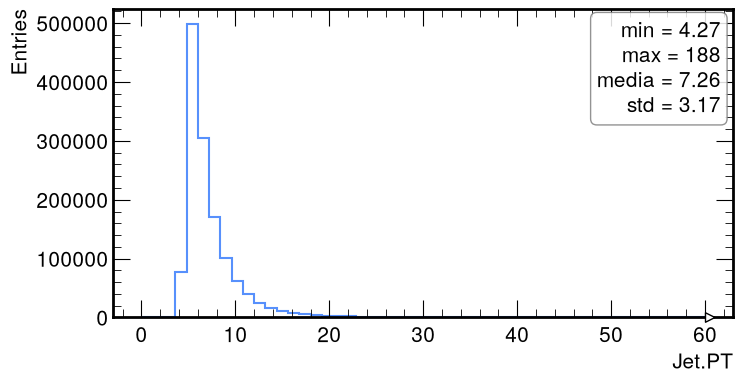

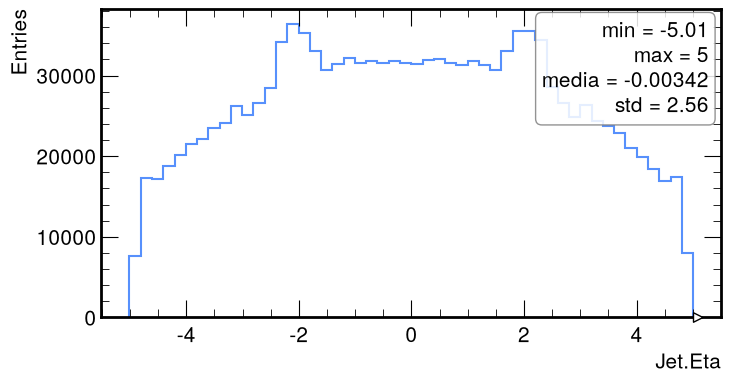

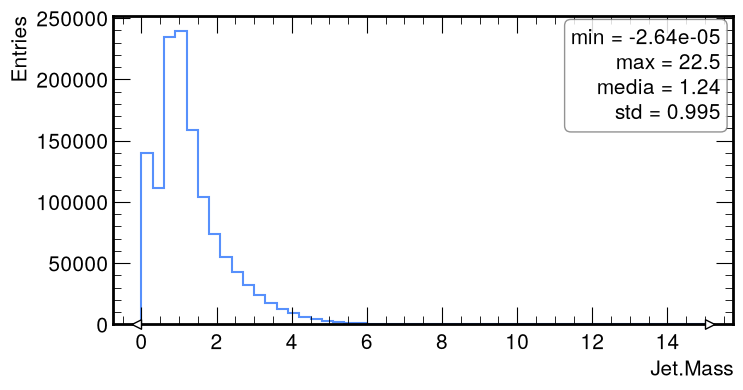

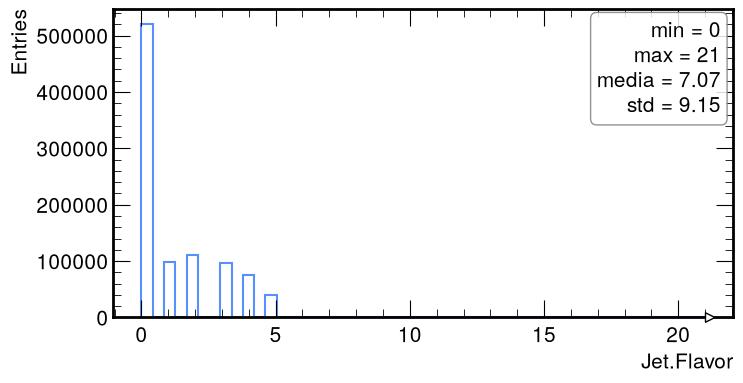

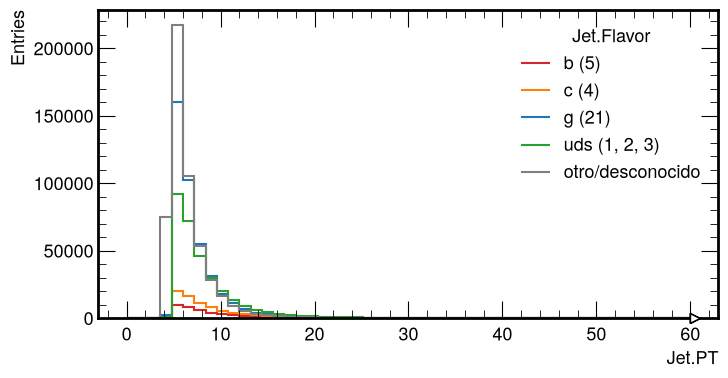

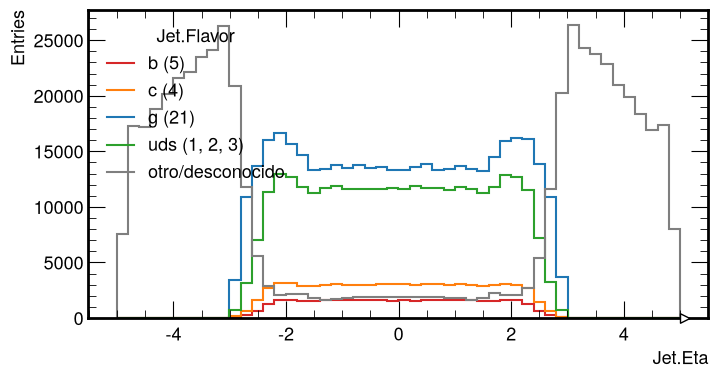

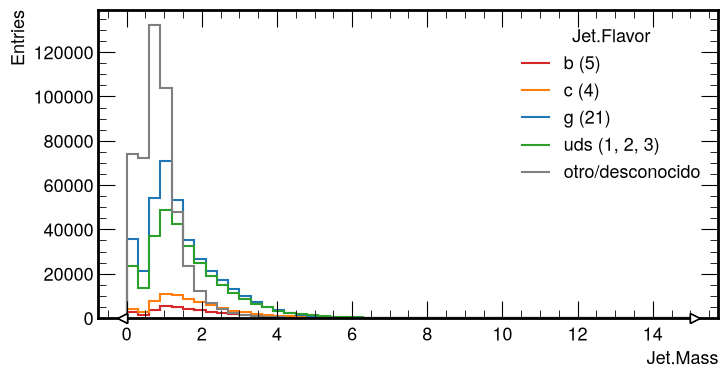

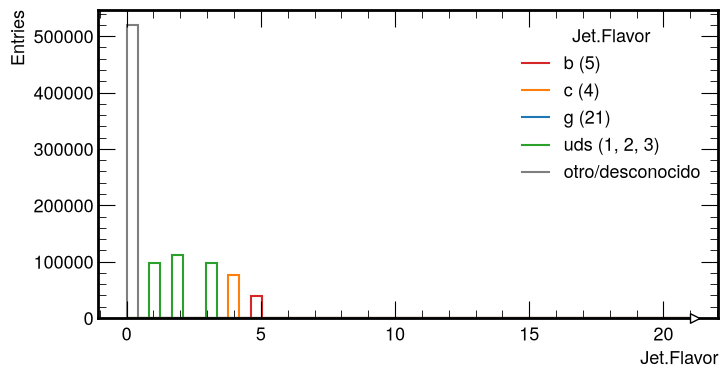

In [6]:
files = [
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_commissioning_200k_20260922/processes/QCD_bbbar_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_commissioning_200k_20260922/processes/QCD_ccbar_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_commissioning_200k_20260922/processes/QCD_ccbar_lowpt/Events/run_02/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_commissioning_200k_20260922/processes/QCD_gg_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_commissioning_200k_20260922/processes/QCD_uds_u_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_commissioning_200k_20260922/processes/QCD_uds_d_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_commissioning_200k_20260922/processes/QCD_uds_s_lowpt/Events/run_01/tag_1_delphes_events.root",
]

plot("Jet.PT", rango=(0, 60))
plot("Jet.Eta")
plot("Jet.Mass", rango = (0, 15))
plot("Jet.Flavor")
plot_por_sabor("Jet.PT", rango=(0, 60))
plot_por_sabor("Jet.Eta")
plot_por_sabor("Jet.Mass", rango = (0, 15))
plot_por_sabor("Jet.Flavor")

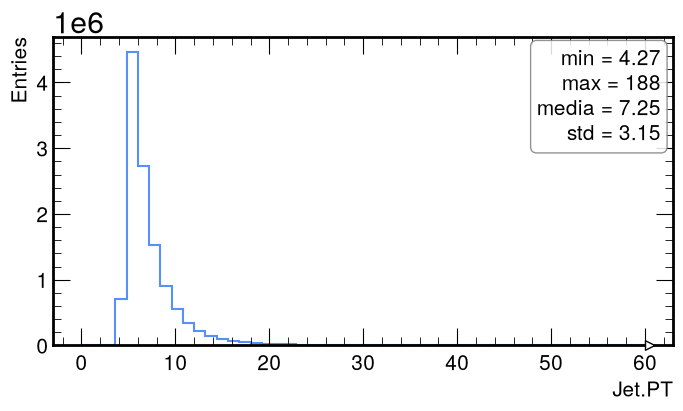

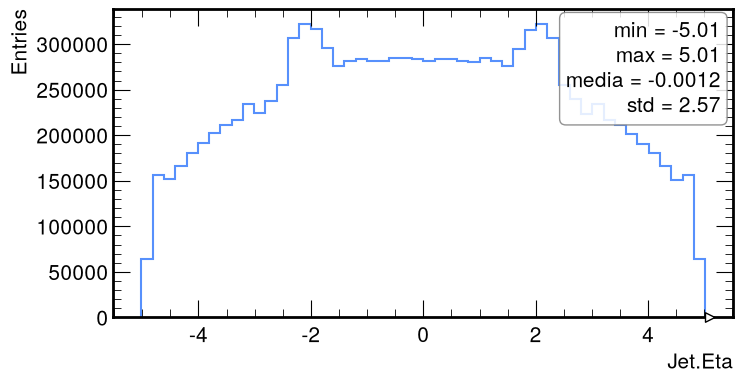

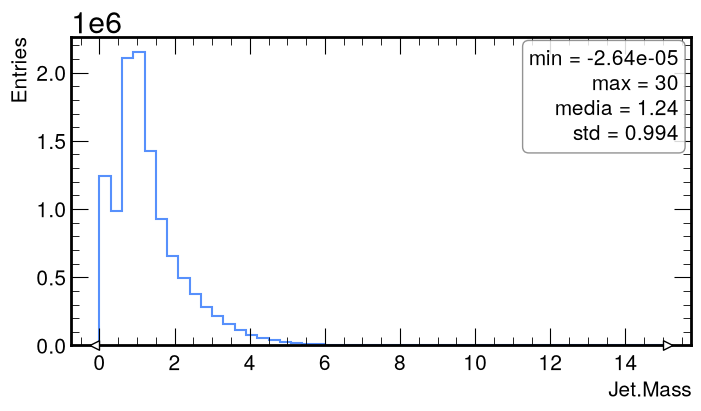

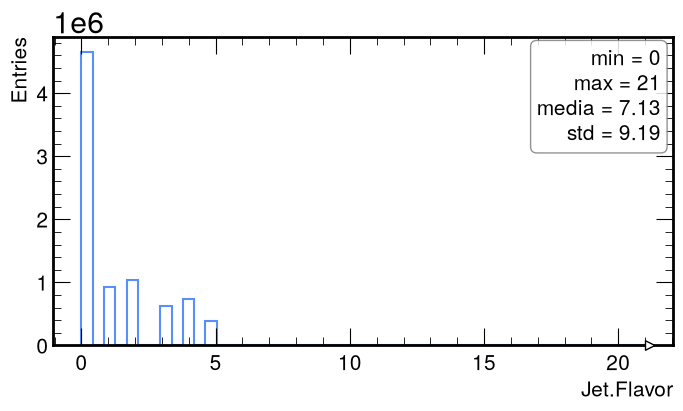

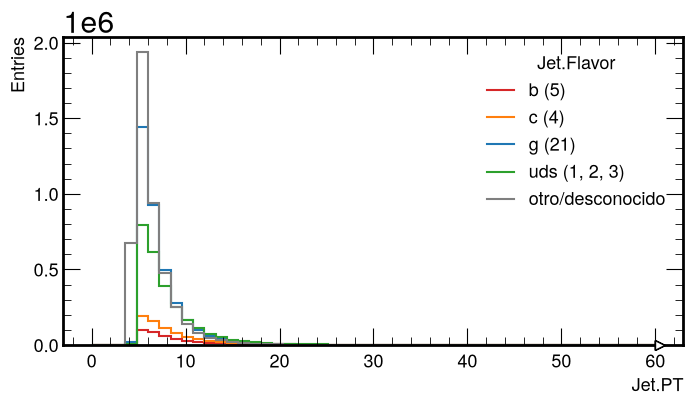

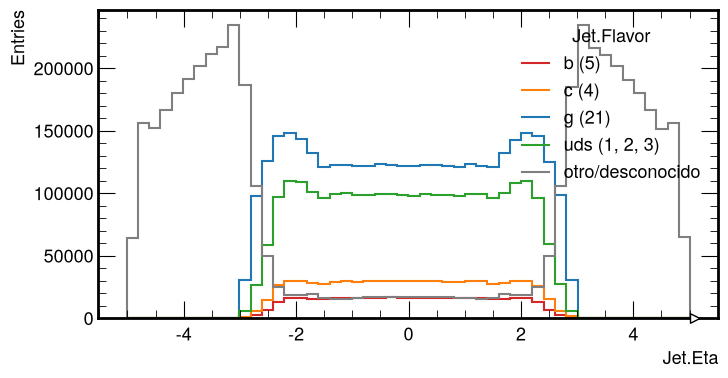

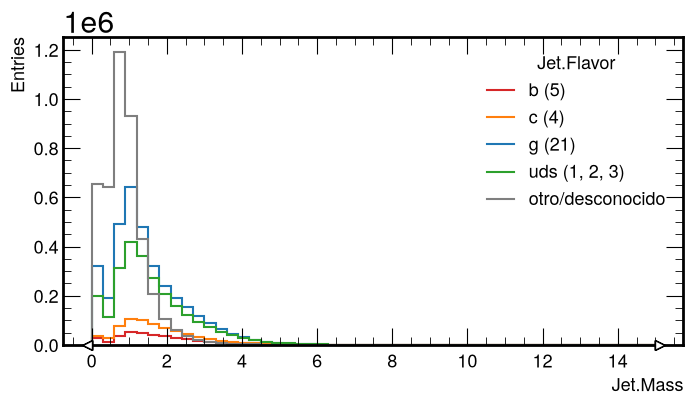

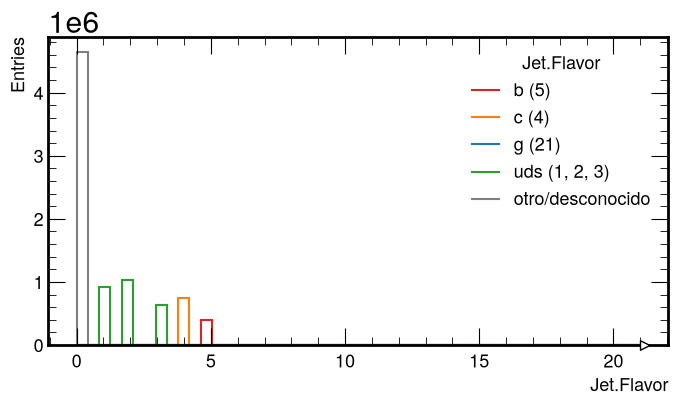

In [10]:
files = [
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_bbbar_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_bbbar_lowpt/Events/run_02/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_bbbar_lowpt/Events/run_03/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_bbbar_lowpt/Events/run_04/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_bbbar_lowpt/Events/run_05/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_bbbar_lowpt/Events/run_06/tag_1_delphes_events.root",   
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_bbbar_lowpt/Events/run_07/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_02/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_03/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_04/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_05/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_06/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_07/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_08/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_09/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_ccbar_lowpt/Events/run_10/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_gg_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_gg_lowpt/Events/run_02/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_gg_lowpt/Events/run_03/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_gg_lowpt/Events/run_04/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_gg_lowpt/Events/run_05/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_gg_lowpt/Events/run_06/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_u_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_u_lowpt/Events/run_02/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_u_lowpt/Events/run_03/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_u_lowpt/Events/run_04/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_u_lowpt/Events/run_05/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_u_lowpt/Events/run_06/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_d_lowpt/Events/run_01/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_d_lowpt/Events/run_02/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_d_lowpt/Events/run_03/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_d_lowpt/Events/run_04/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_d_lowpt/Events/run_05/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_d_lowpt/Events/run_06/tag_1_delphes_events.root",
    "/home/juanm/mg5amcnlo/campaigns/btag_v4_effective_2m_20260925/processes/QCD_uds_s_lowpt/Events/run_01/tag_1_delphes_events.root"
]

plot("Jet.PT", rango=(0, 60))
plot("Jet.Eta")
plot("Jet.Mass", rango = (0, 15))
plot("Jet.Flavor")
plot_por_sabor("Jet.PT", rango=(0, 60))
plot_por_sabor("Jet.Eta")
plot_por_sabor("Jet.Mass", rango = (0, 15))
plot_por_sabor("Jet.Flavor")